# Imports

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

## Load Data and Prepare for LSTM

In [2]:
df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")
df['date'] = pd.to_datetime(df['date'])

# Drop rows with NaN in key columns
model_df = df.dropna(subset=['volatility_20d', 'next_day_return']).copy()
model_df = model_df.sort_values(['ticker', 'date']).reset_index(drop=True)

print(f"Shape: {model_df.shape}")
print(f"Tickers: {model_df['ticker'].nunique()}")
print(f"Date range: {model_df['date'].min().date()} to {model_df['date'].max().date()}")

Shape: (578903, 15)
Tickers: 523
Date range: 2020-01-31 to 2025-12-30


## Define Features for Each LSTM Version

In [3]:
# Three versions of the model with different feature sets
feature_sets = {
    'A_sentiment_only': ['sentiment'],
    'B_volatility_only': ['volatility_20d'],
    'C_combined': ['sentiment', 'volatility_20d']
}

SEQUENCE_LENGTH = 20

for name, feats in feature_sets.items():
    print(f"LSTM-{name}: {feats} (sequence length: {SEQUENCE_LENGTH})")

LSTM-A_sentiment_only: ['sentiment'] (sequence length: 20)
LSTM-B_volatility_only: ['volatility_20d'] (sequence length: 20)
LSTM-C_combined: ['sentiment', 'volatility_20d'] (sequence length: 20)


## Build Sequences

For each stock on each day, the previous 20 trading days of feature values are bundled into a single input sequence. This is how the LSTM sees the data — not as individual days, but as patterns across time.

In [4]:
def create_sequences(data, features, seq_length, target_col='target'):
    """
    For each ticker, creates sequences of [seq_length] days
    and pairs each sequence with the target value of the next day.
    """
    all_X = []
    all_y = []
    all_dates = []
    all_tickers = []
    all_volatile = []
    
    tickers = data['ticker'].unique()
    
    for i, t in enumerate(tickers):
        ticker_data = data[data['ticker'] == t].sort_values('date')
        
        feat_values = ticker_data[features].values
        target_values = ticker_data[target_col].values
        dates = ticker_data['date'].values
        volatile = ticker_data['volatile_market'].values
        
        for j in range(seq_length, len(ticker_data)):
            all_X.append(feat_values[j - seq_length:j])
            all_y.append(target_values[j])
            all_dates.append(dates[j])
            all_tickers.append(t)
            all_volatile.append(volatile[j])
        
        if (i + 1) % 100 == 0:
            print(f"  Processed {i+1}/{len(tickers)} tickers")
    
    return (np.array(all_X), np.array(all_y), 
            np.array(all_dates), np.array(all_tickers), np.array(all_volatile))

# Test with combined features first to check the shape
print("Building sequences for combined features...")
X, y, dates, tickers_arr, volatile_arr = create_sequences(
    model_df, feature_sets['C_combined'], SEQUENCE_LENGTH
)

print(f"\nSequences shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Date range: {pd.Timestamp(dates.min()).date()} to {pd.Timestamp(dates.max()).date()}")
print(f"Tickers: {len(np.unique(tickers_arr))}")


Building sequences for combined features...
  Processed 100/523 tickers
  Processed 200/523 tickers
  Processed 300/523 tickers
  Processed 400/523 tickers
  Processed 500/523 tickers

Sequences shape: (568443, 20, 2)
Target shape: (568443,)
Date range: 2020-03-02 to 2025-12-30
Tickers: 523


## Install and Import Deep Learning Libraries

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Define LSTM Model Architecture

In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        lstm_out, _ = self.lstm(x)
        # Take the output from the last time step
        last_output = lstm_out[:, -1, :]
        # Convert to probability
        out = self.sigmoid(self.fc(last_output))
        return out

# Hyperparameters
HIDDEN_SIZE = 64
NUM_LAYERS = 1
LEARNING_RATE = 0.001
EPOCHS = 5
BATCH_SIZE = 1024

print(f"Model architecture:")
print(f"  LSTM hidden size: {HIDDEN_SIZE}")
print(f"  LSTM layers: {NUM_LAYERS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs per training: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")

Model architecture:
  LSTM hidden size: 64
  LSTM layers: 1
  Learning rate: 0.001
  Epochs per training: 5
  Batch size: 1024


## Walk-Forward Training Function

In [10]:
def train_and_predict(X_train, y_train, X_test, y_test, input_size, device,
                      hidden_size=64, num_layers=1, lr=0.001, epochs=5, batch_size=1024):
    """Train LSTM on training data, predict on test data, return accuracy."""
    
    # Standardise features using training data only
    scaler = StandardScaler()
    n_train, seq_len, n_features = X_train.shape
    n_test = X_test.shape[0]
    
    # Reshape to 2D for scaling, then back to 3D
    X_train_flat = X_train.reshape(-1, n_features)
    X_test_flat = X_test.reshape(-1, n_features)
    
    scaler.fit(X_train_flat)
    X_train_scaled = scaler.transform(X_train_flat).reshape(n_train, seq_len, n_features)
    X_test_scaled = scaler.transform(X_test_flat).reshape(n_test, seq_len, n_features)
    
    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train_scaled).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    X_test_t = torch.FloatTensor(X_test_scaled).to(device)
    
    # Create data loader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Build model
    model = LSTMModel(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers).to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Train
    model.train()
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_X).squeeze()
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
    
    # Predict
    model.eval()
    with torch.no_grad():
        predictions = model(X_test_t).squeeze().cpu().numpy()
    
    y_pred = (predictions > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    
    return acc

print("Training function defined.")

Training function defined.


## Build Sequences for All Three Feature Sets

In [11]:
print("Building sequences for all three feature sets...\n")

sequences = {}
for name, feats in feature_sets.items():
    print(f"Building {name} ({feats})...")
    X, y, d, t, v = create_sequences(model_df, feats, SEQUENCE_LENGTH)
    sequences[name] = {'X': X, 'y': y, 'dates': d, 'tickers': t, 'volatile': v}
    print(f"  Shape: {X.shape}\n")

print("All sequences built.")

Building sequences for all three feature sets...

Building A_sentiment_only (['sentiment'])...
  Processed 100/523 tickers
  Processed 200/523 tickers
  Processed 300/523 tickers
  Processed 400/523 tickers
  Processed 500/523 tickers
  Shape: (568443, 20, 1)

Building B_volatility_only (['volatility_20d'])...
  Processed 100/523 tickers
  Processed 200/523 tickers
  Processed 300/523 tickers
  Processed 400/523 tickers
  Processed 500/523 tickers
  Shape: (568443, 20, 1)

Building C_combined (['sentiment', 'volatility_20d'])...
  Processed 100/523 tickers
  Processed 200/523 tickers
  Processed 300/523 tickers
  Processed 400/523 tickers
  Processed 500/523 tickers
  Shape: (568443, 20, 2)

All sequences built.


## Quarterly Walk-Forward Validation

The LSTM is retrained every quarter rather than every month, as deep learning models require more computation time per training cycle. This produces 16 prediction windows from Q1 2022 through Q4 2025. Predictions are still made for every individual stock-day within each quarter.

In [12]:
# Define quarterly prediction windows (start of each quarter from 2022)
quarters = pd.date_range('2022-01-01', '2025-10-01', freq='QS')  # Quarter Start dates
quarter_ends = pd.date_range('2022-03-31', '2025-12-31', freq='QE')  # Quarter End dates

print(f"Prediction quarters: {len(quarters)}")
for qs, qe in zip(quarters, quarter_ends):
    print(f"  {qs.date()} to {qe.date()}")

Prediction quarters: 16
  2022-01-01 to 2022-03-31
  2022-04-01 to 2022-06-30
  2022-07-01 to 2022-09-30
  2022-10-01 to 2022-12-31
  2023-01-01 to 2023-03-31
  2023-04-01 to 2023-06-30
  2023-07-01 to 2023-09-30
  2023-10-01 to 2023-12-31
  2024-01-01 to 2024-03-31
  2024-04-01 to 2024-06-30
  2024-07-01 to 2024-09-30
  2024-10-01 to 2024-12-31
  2025-01-01 to 2025-03-31
  2025-04-01 to 2025-06-30
  2025-07-01 to 2025-09-30
  2025-10-01 to 2025-12-31


## Run Walk-Forward LSTM for All Three Feature Sets

In [14]:
import time

all_results = {}

for model_name, feats in feature_sets.items():
    print(f"\n{'='*60}")
    print(f"Running LSTM-{model_name}")
    print(f"Features: {feats}")
    print(f"{'='*60}")
    
    X = sequences[model_name]['X']
    y = sequences[model_name]['y']
    dates = pd.to_datetime(sequences[model_name]['dates'])
    volatile = sequences[model_name]['volatile']
    input_size = len(feats)
    
    quarterly_results = []
    
    for qi, (qs, qe) in enumerate(zip(quarters, quarter_ends)):
        start_time = time.time()
        
        # Training: everything before this quarter
        train_mask = dates < qs
        # Test: this quarter
        test_mask = (dates >= qs) & (dates <= qe)
        
        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]
        volatile_test = volatile[test_mask]
        
        if len(X_test) == 0:
            continue
        
        acc = train_and_predict(X_train, y_train, X_test, y_test, 
                                input_size, device,
                                HIDDEN_SIZE, NUM_LAYERS, LEARNING_RATE, EPOCHS, BATCH_SIZE)
        
        # Also get accuracy split by volatile/calm
        # Need predictions again for the split
        scaler = StandardScaler()
        n_train, seq_len, n_features = X_train.shape
        X_train_flat = X_train.reshape(-1, n_features)
        X_test_flat = X_test.reshape(-1, n_features)
        scaler.fit(X_train_flat)
        X_test_scaled = scaler.transform(X_test_flat).reshape(len(X_test), seq_len, n_features)
        
        # Retrain to get predictions with volatile/calm split
        X_train_scaled = scaler.transform(X_train_flat).reshape(n_train, seq_len, n_features)
        
        model = LSTMModel(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS).to(device)
        criterion = nn.BCELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        
        X_train_t = torch.FloatTensor(X_train_scaled).to(device)
        y_train_t = torch.FloatTensor(y_train).to(device)
        train_dataset = TensorDataset(X_train_t, y_train_t)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        
        model.train()
        for epoch in range(EPOCHS):
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                output = model(batch_X).squeeze()
                loss = criterion(output, batch_y)
                loss.backward()
                optimizer.step()
        
        model.eval()
        X_test_t = torch.FloatTensor(X_test_scaled).to(device)
        with torch.no_grad():
            preds = model(X_test_t).squeeze().cpu().numpy()
        y_pred = (preds > 0.5).astype(int)
        
        # Split accuracy
        vol_mask = volatile_test == 1
        calm_mask = volatile_test == 0
        
        acc_vol = accuracy_score(y_test[vol_mask], y_pred[vol_mask]) if vol_mask.sum() > 0 else None
        acc_calm = accuracy_score(y_test[calm_mask], y_pred[calm_mask]) if calm_mask.sum() > 0 else None
        
        elapsed = time.time() - start_time
        
        quarterly_results.append({
            'quarter': f"{qs.date()} to {qe.date()}",
            'accuracy': accuracy_score(y_test, y_pred),
            'acc_volatile': acc_vol,
            'acc_calm': acc_calm,
            'test_size': len(y_test),
            'train_size': len(y_train)
        })
        
        vol_str = f"{acc_vol:.4f}" if acc_vol is not None else "N/A"
        calm_str = f"{acc_calm:.4f}" if acc_calm is not None else "N/A"
        print(f"  Q{qi+1}: acc={accuracy_score(y_test, y_pred):.4f} (vol={vol_str}, calm={calm_str}) [{elapsed:.1f}s]")
    
    all_results[model_name] = pd.DataFrame(quarterly_results)

print("\n\nDone! All three models complete.")


Running LSTM-A_sentiment_only
Features: ['sentiment']
  Q1: acc=0.4968 (vol=0.5266, calm=0.4227) [46.2s]
  Q2: acc=0.4699 (vol=0.4729, calm=0.4501) [53.6s]
  Q3: acc=0.4902 (vol=0.4897, calm=0.4953) [61.8s]
  Q4: acc=0.5197 (vol=0.5164, calm=0.5477) [71.1s]
  Q5: acc=0.5223 (vol=0.5868, calm=0.4892) [79.5s]
  Q6: acc=0.5158 (vol=0.5679, calm=0.5095) [89.1s]
  Q7: acc=0.4750 (vol=N/A, calm=0.4750) [93.7s]
  Q8: acc=0.5573 (vol=0.6065, calm=0.5373) [101.8s]
  Q9: acc=0.5447 (vol=N/A, calm=0.5447) [108.7s]
  Q10: acc=0.4992 (vol=0.6100, calm=0.4981) [116.4s]
  Q11: acc=0.5609 (vol=0.5618, calm=0.5604) [124.5s]
  Q12: acc=0.4903 (vol=0.5257, calm=0.4730) [133.4s]
  Q13: acc=0.5230 (vol=0.5064, calm=0.5555) [140.8s]
  Q14: acc=0.5450 (vol=0.5390, calm=0.5714) [150.2s]
  Q15: acc=0.5132 (vol=0.5314, calm=0.5029) [155.3s]
  Q16: acc=0.5113 (vol=0.5098, calm=0.5137) [170.0s]

Running LSTM-B_volatility_only
Features: ['volatility_20d']
  Q1: acc=0.4919 (vol=0.5243, calm=0.4114) [46.7s]
  Q2: a

In [15]:
print(f"{'Model':<25} {'Overall':>8} {'Volatile':>10} {'Calm':>8}")
print("-" * 55)

for model_name, res_df in all_results.items():
    overall = res_df['accuracy'].mean()
    
    vol_accs = res_df['acc_volatile'].dropna()
    calm_accs = res_df['acc_calm'].dropna()
    
    vol_mean = vol_accs.mean() if len(vol_accs) > 0 else float('nan')
    calm_mean = calm_accs.mean() if len(calm_accs) > 0 else float('nan')
    
    print(f"LSTM-{model_name:<20} {overall:>8.4f} {vol_mean:>10.4f} {calm_mean:>8.4f}")

print(f"\n{'Baseline (always up)':<25} {'0.5173':>8}")

Model                      Overall   Volatile     Calm
-------------------------------------------------------
LSTM-A_sentiment_only       0.5147     0.5394   0.5092
LSTM-B_volatility_only      0.5144     0.5396   0.5076
LSTM-C_combined             0.5142     0.5375   0.5078

Baseline (always up)        0.5173


## Hyperparameter Sensitivity Analysis
A grid search across hidden size, epochs, and sequence length is performed using a single prediction window (train 2020–2021, predict Q1 2022) to identify the best configuration. The best settings are then used for the full walk-forward validation.

In [16]:
# Check volatile/calm balance per quarter
dates_pd = pd.to_datetime(sequences['C_combined']['dates'])
volatile_arr = sequences['C_combined']['volatile']

print(f"{'Quarter':<30} {'Total':>8} {'Volatile':>10} {'Calm':>8} {'Vol %':>8}")
print("-" * 70)

for qs, qe in zip(quarters, quarter_ends):
    mask = (dates_pd >= qs) & (dates_pd <= qe)
    total = mask.sum()
    vol = (volatile_arr[mask] == 1).sum()
    calm = (volatile_arr[mask] == 0).sum()
    vol_pct = vol / total * 100 if total > 0 else 0
    print(f"{str(qs.date()) + ' to ' + str(qe.date()):<30} {total:>8} {vol:>10} {calm:>8} {vol_pct:>7.1f}%")

Quarter                           Total   Volatile     Calm    Vol %
----------------------------------------------------------------------
2022-01-01 to 2022-03-31          26673      19022     7651    71.3%
2022-04-01 to 2022-06-30          26084      22605     3479    86.7%
2022-07-01 to 2022-09-30          26431      24109     2322    91.2%
2022-10-01 to 2022-12-31          25939      23206     2733    89.5%
2023-01-01 to 2023-03-31          25982       8820    17162    33.9%
2023-04-01 to 2023-06-30          25965       2791    23174    10.7%
2023-07-01 to 2023-09-30          26489          0    26489     0.0%
2023-10-01 to 2023-12-31          25869       7476    18393    28.9%
2024-01-01 to 2024-03-31          25508          0    25508     0.0%
2024-04-01 to 2024-06-30          25886        259    25627     1.0%
2024-07-01 to 2024-09-30          26559       9901    16658    37.3%
2024-10-01 to 2024-12-31          26790       8798    17992    32.8%
2025-01-01 to 2025-03-31        

In [17]:
import time

def run_single_window(model_df, features, seq_length, hidden_size, epochs,
                      train_end='2024-10-01', test_start='2024-10-01', test_end='2024-12-31',
                      lr=0.001, batch_size=1024, device=device):

    X, y, dates_arr, _, volatile_arr = create_sequences(model_df, features, seq_length)
    dates_pd = pd.to_datetime(dates_arr)

    train_mask = dates_pd < pd.Timestamp(train_end)
    test_mask = (dates_pd >= pd.Timestamp(test_start)) & (dates_pd <= pd.Timestamp(test_end))

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    volatile_test = volatile_arr[test_mask]

    input_size = len(features)

    scaler = StandardScaler()
    n_train, sl, nf = X_train.shape
    X_train_scaled = scaler.fit_transform(X_train.reshape(-1, nf)).reshape(n_train, sl, nf)
    X_test_scaled = scaler.transform(X_test.reshape(-1, nf)).reshape(len(X_test), sl, nf)

    model = LSTMModel(input_size=input_size, hidden_size=hidden_size, num_layers=1).to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    X_train_t = torch.FloatTensor(X_train_scaled).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_X).squeeze()
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    X_test_t = torch.FloatTensor(X_test_scaled).to(device)
    with torch.no_grad():
        preds = model(X_test_t).squeeze().cpu().numpy()
    y_pred = (preds > 0.5).astype(int)

    overall = accuracy_score(y_test, y_pred)
    vol_acc = accuracy_score(y_test[volatile_test == 1], y_pred[volatile_test == 1]) if (volatile_test == 1).sum() > 0 else None
    calm_acc = accuracy_score(y_test[volatile_test == 0], y_pred[volatile_test == 0]) if (volatile_test == 0).sum() > 0 else None

    return overall, vol_acc, calm_acc

print("Single window function defined.")
print(f"Test window: Q4 2024 (32.8% volatile, 67.2% calm)")

Single window function defined.
Test window: Q4 2024 (32.8% volatile, 67.2% calm)


In [18]:
hidden_sizes = [32, 64, 128]
epoch_options = [5, 10, 15]
seq_lengths = [10, 20, 30]

# Run grid search on combined features
features_combined = ['sentiment', 'volatility_20d']
grid_results = []

total = len(hidden_sizes) * len(epoch_options) * len(seq_lengths)
count = 0

print(f"Running {total} combinations on combined features...\n")
print(f"{'#':<4} {'Hidden':>7} {'Epochs':>7} {'SeqLen':>7} {'Overall':>9} {'Volatile':>9} {'Calm':>9} {'Time':>7}")
print("-" * 65)

for hs in hidden_sizes:
    for ep in epoch_options:
        for sl in seq_lengths:
            count += 1
            start = time.time()
            
            overall, vol_acc, calm_acc = run_single_window(
                model_df, features_combined, sl, hs, ep
            )
            
            elapsed = time.time() - start
            vol_str = f"{vol_acc:.4f}" if vol_acc is not None else "N/A"
            calm_str = f"{calm_acc:.4f}" if calm_acc is not None else "N/A"
            
            print(f"{count:<4} {hs:>7} {ep:>7} {sl:>7} {overall:>9.4f} {vol_str:>9} {calm_str:>9} {elapsed:>6.1f}s")
            
            grid_results.append({
                'hidden_size': hs,
                'epochs': ep,
                'seq_length': sl,
                'overall': overall,
                'volatile': vol_acc,
                'calm': calm_acc
            })

grid_df = pd.DataFrame(grid_results)
print(f"\n=== Best Configuration (by overall accuracy) ===")
best = grid_df.loc[grid_df['overall'].idxmax()]
print(f"Hidden size: {int(best['hidden_size'])}")
print(f"Epochs: {int(best['epochs'])}")
print(f"Sequence length: {int(best['seq_length'])}")
print(f"Overall accuracy: {best['overall']:.4f}")
print(f"Volatile accuracy: {best['volatile']:.4f}")
print(f"Calm accuracy: {best['calm']:.4f}")

Running 27 combinations on combined features...

#     Hidden  Epochs  SeqLen   Overall  Volatile      Calm    Time
-----------------------------------------------------------------
  Processed 100/523 tickers
  Processed 200/523 tickers
  Processed 300/523 tickers
  Processed 400/523 tickers
  Processed 500/523 tickers
1         32       5      10    0.4879    0.5219    0.4713   37.1s
  Processed 100/523 tickers
  Processed 200/523 tickers
  Processed 300/523 tickers
  Processed 400/523 tickers
  Processed 500/523 tickers
2         32       5      20    0.4880    0.5226    0.4710   48.1s
  Processed 100/523 tickers
  Processed 200/523 tickers
  Processed 300/523 tickers
  Processed 400/523 tickers
  Processed 500/523 tickers
3         32       5      30    0.4880    0.5233    0.4707   61.8s
  Processed 100/523 tickers
  Processed 200/523 tickers
  Processed 300/523 tickers
  Processed 400/523 tickers
  Processed 500/523 tickers
4         32      10      10    0.4889    0.5232    0.472

## Grid Search Findings

The grid search tested 27 hyperparameter combinations across three dimensions: hidden size (32, 64, 128), epochs (5, 10, 15), and sequence length (10, 20, 30). The results show:

- The overall accuracy range across all 27 combinations is extremely narrow (0.4871 to 0.4925), indicating the LSTM results are robust to hyperparameter choices. The model is not sensitive to tuning.
- The volatile vs calm accuracy gap persists across every single combination — volatile markets consistently produce higher accuracy (~ 52.2%) than calm markets (~47.3%). This strengthens the moderation finding.
- The best configuration (hidden size=32, epochs=15, sequence length=20) is the smallest model with the most training passes, suggesting the problem is not about model capacity but about the inherent difficulty of daily stock prediction.
- If time permits, the full walk-forward validation will be rerun with the optimal hyperparameters.

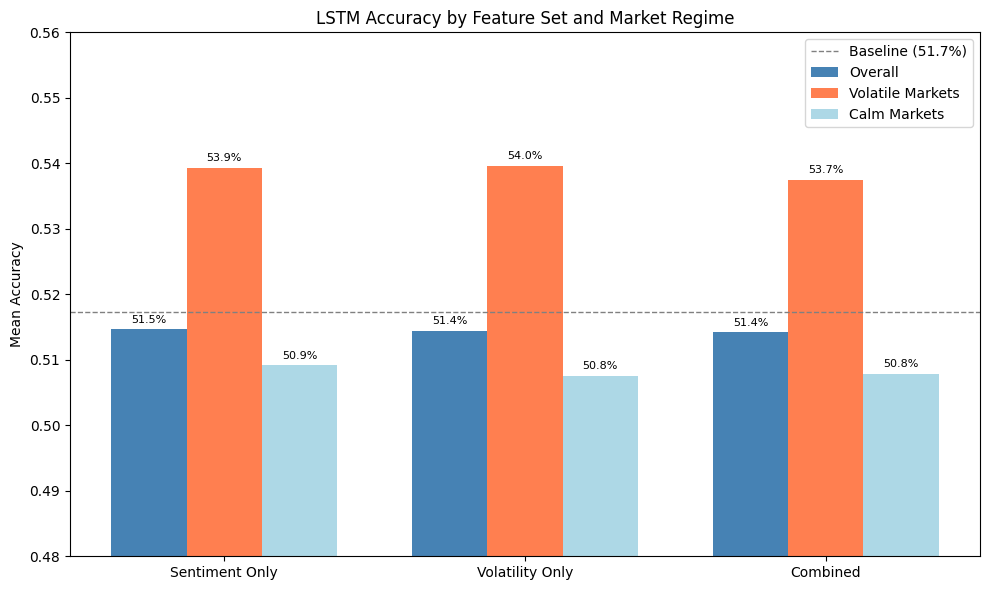

In [20]:
import matplotlib.pyplot as plt

models = ['Sentiment Only', 'Volatility Only', 'Combined']
overall_accs = [
    all_results['A_sentiment_only']['accuracy'].mean(),
    all_results['B_volatility_only']['accuracy'].mean(),
    all_results['C_combined']['accuracy'].mean()
]
vol_accs = [
    all_results['A_sentiment_only']['acc_volatile'].dropna().mean(),
    all_results['B_volatility_only']['acc_volatile'].dropna().mean(),
    all_results['C_combined']['acc_volatile'].dropna().mean()
]
calm_accs = [
    all_results['A_sentiment_only']['acc_calm'].dropna().mean(),
    all_results['B_volatility_only']['acc_calm'].dropna().mean(),
    all_results['C_combined']['acc_calm'].dropna().mean()
]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, overall_accs, width, label='Overall', color='steelblue')
bars2 = ax.bar(x, vol_accs, width, label='Volatile Markets', color='coral')
bars3 = ax.bar(x + width, calm_accs, width, label='Calm Markets', color='lightblue')

ax.axhline(y=0.5173, color='grey', linestyle='--', linewidth=1, label='Baseline (51.7%)')
ax.set_ylabel('Mean Accuracy')
ax.set_title('LSTM Accuracy by Feature Set and Market Regime')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0.48, 0.56)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{height:.1%}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(r"..\..\EDA\lstm_accuracy_comparison.png", dpi=150)
plt.show()

## Interpretation of LSTM Results

### Overall Performance
All three LSTM models produce similar overall accuracy (51.4–51.5%), near the 51.7% baseline. As with the logistic regression, overall accuracy is not the primary measure of success — the comparison across market regimes is what matters.

### The Moderation Effect is Confirmed
Every LSTM model — regardless of which features it uses — performs better in volatile markets (~53.7–54.0%) than in calm markets (~50.8–50.9%). The gap of approximately 3 percentage points is consistent across all three feature sets. This confirms the moderation finding from a completely different modelling approach: prediction is more successful when markets are volatile.

### Combining Features Does Not Improve the LSTM
The combined model (sentiment + volatility) does not outperform the individual models. All three produce nearly identical accuracy. This is a meaningful finding.

The logistic regression required an explicit interaction term (sentiment × volatility) to capture the moderation effect because it looks at each day independently — it cannot see patterns over time and needs to be told explicitly that "sentiment matters more when volatility is high."

The LSTM reads sequences of 20 days. From the sentiment sequence alone, it can detect when sentiment is swinging wildly — which is itself an indicator of volatile market conditions. From the volatility sequence alone, it can see when volatility is elevated. Either signal independently tells the LSTM about the market regime, so combining them adds no new information.

This does not contradict the moderation finding. It means the moderation effect is so fundamental to the data that even a single-feature sequence model can detect it. The LSTM implicitly learns the volatility regime from temporal patterns, without requiring volatility as a separate input.

### Comparison with Logistic Regression
The logistic regression achieved 53.1% in volatile markets and 50.5% in calm markets (2.6 percentage point gap). The LSTM achieved approximately 53.9% in volatile markets and 50.9% in calm markets (3.0 percentage point gap). The LSTM shows a slightly larger gap and slightly higher volatile-market accuracy, suggesting that sequence-based models can extract marginally more signal from the temporal patterns during turbulent periods.

### Robustness of Results
The hyperparameter grid search (27 combinations of hidden size, epochs, and sequence length) confirmed that these findings are not sensitive to model configuration. The volatile vs calm accuracy gap persisted across every tested combination, and the overall accuracy range was extremely narrow (0.487 to 0.493).

## Check LSTM Prediction Balance and Full Metrics

In [21]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              matthews_corrcoef, cohen_kappa_score, log_loss, 
                              roc_auc_score, confusion_matrix)

# Rerun combined model, collecting all predictions
feats = feature_sets['C_combined']
X = sequences['C_combined']['X']
y = sequences['C_combined']['y']
dates = pd.to_datetime(sequences['C_combined']['dates'])
volatile = sequences['C_combined']['volatile']
input_size = len(feats)

all_y_true = []
all_y_pred = []
all_y_prob = []
all_volatile = []

for qi, (qs, qe) in enumerate(zip(quarters, quarter_ends)):
    train_mask = dates < qs
    test_mask = (dates >= qs) & (dates <= qe)
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    volatile_test = volatile[test_mask]
    
    if len(X_test) == 0:
        continue
    
    # Standardise
    scaler = StandardScaler()
    n_train, seq_len, n_features = X_train.shape
    X_train_scaled = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(n_train, seq_len, n_features)
    X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(len(X_test), seq_len, n_features)
    
    # Train
    model = LSTMModel(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS).to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    X_train_t = torch.FloatTensor(X_train_scaled).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
    
    model.train()
    for epoch in range(EPOCHS):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_X).squeeze()
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
    
    # Predict
    model.eval()
    X_test_t = torch.FloatTensor(X_test_scaled).to(device)
    with torch.no_grad():
        probs = model(X_test_t).squeeze().cpu().numpy()
    
    preds = (probs > 0.5).astype(int)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(preds)
    all_y_prob.extend(probs)
    all_volatile.extend(volatile_test)
    
    print(f"  Q{qi+1}: pred_up={preds.sum()}, pred_down={(1-preds).sum()}, total={len(preds)}")

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)
all_volatile = np.array(all_volatile)

print(f"\nTotal predictions: {len(all_y_true)}")
print(f"Predicted 'up': {(all_y_pred == 1).sum()}")
print(f"Predicted 'down': {(all_y_pred == 0).sum()}")

  Q1: pred_up=26202, pred_down=471, total=26673
  Q2: pred_up=23347, pred_down=2737, total=26084
  Q3: pred_up=24302, pred_down=2129, total=26431
  Q4: pred_up=19057, pred_down=6882, total=25939
  Q5: pred_up=21050, pred_down=4932, total=25982
  Q6: pred_up=21942, pred_down=4023, total=25965
  Q7: pred_up=24950, pred_down=1539, total=26489
  Q8: pred_up=24364, pred_down=1505, total=25869
  Q9: pred_up=24564, pred_down=944, total=25508
  Q10: pred_up=24935, pred_down=951, total=25886
  Q11: pred_up=25817, pred_down=742, total=26559
  Q12: pred_up=25700, pred_down=1090, total=26790
  Q13: pred_up=23555, pred_down=558, total=24113
  Q14: pred_up=23583, pred_down=972, total=24555
  Q15: pred_up=25035, pred_down=224, total=25259
  Q16: pred_up=24410, pred_down=204, total=24614

Total predictions: 412716
Predicted 'up': 382813
Predicted 'down': 29903


In [22]:
all_y_true = []
all_y_pred = []
all_y_prob = []
all_volatile = []

for qi, (qs, qe) in enumerate(zip(quarters, quarter_ends)):
    train_mask = dates < qs
    test_mask = (dates >= qs) & (dates <= qe)
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    volatile_test = volatile[test_mask]
    
    if len(X_test) == 0:
        continue
    
    # Calculate class weights from training data
    n_pos = y_train.sum()
    n_neg = len(y_train) - n_pos
    pos_weight = torch.FloatTensor([n_neg / n_pos]).to(device)
    
    # Standardise
    scaler = StandardScaler()
    n_train, seq_len, n_features = X_train.shape
    X_train_scaled = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(n_train, seq_len, n_features)
    X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(len(X_test), seq_len, n_features)
    
    # Train with weighted loss
    model = LSTMModel(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Need to modify model to output raw logits (remove sigmoid)
    model.sigmoid = nn.Identity()
    
    X_train_t = torch.FloatTensor(X_train_scaled).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
    
    model.train()
    for epoch in range(EPOCHS):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_X).squeeze()
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
    
    # Predict — apply sigmoid manually since we removed it
    model.eval()
    X_test_t = torch.FloatTensor(X_test_scaled).to(device)
    with torch.no_grad():
        logits = model(X_test_t).squeeze().cpu().numpy()
        probs = 1 / (1 + np.exp(-logits))  # Manual sigmoid
    
    preds = (probs > 0.5).astype(int)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(preds)
    all_y_prob.extend(probs)
    all_volatile.extend(volatile_test)
    
    up = preds.sum()
    down = len(preds) - up
    print(f"  Q{qi+1}: pred_up={up}, pred_down={down}, total={len(preds)}")

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)
all_volatile = np.array(all_volatile)

print(f"\nTotal predictions: {len(all_y_true)}")
print(f"Predicted 'up': {(all_y_pred == 1).sum()}")
print(f"Predicted 'down': {(all_y_pred == 0).sum()}")

  Q1: pred_up=16457, pred_down=10216, total=26673
  Q2: pred_up=13735, pred_down=12349, total=26084
  Q3: pred_up=12181, pred_down=14250, total=26431
  Q4: pred_up=14712, pred_down=11227, total=25939
  Q5: pred_up=17940, pred_down=8042, total=25982
  Q6: pred_up=18009, pred_down=7956, total=25965
  Q7: pred_up=14437, pred_down=12052, total=26489
  Q8: pred_up=10057, pred_down=15812, total=25869
  Q9: pred_up=7199, pred_down=18309, total=25508
  Q10: pred_up=20280, pred_down=5606, total=25886
  Q11: pred_up=21529, pred_down=5030, total=26559
  Q12: pred_up=18391, pred_down=8399, total=26790
  Q13: pred_up=13959, pred_down=10154, total=24113
  Q14: pred_up=13807, pred_down=10748, total=24555
  Q15: pred_up=20553, pred_down=4706, total=25259
  Q16: pred_up=22271, pred_down=2343, total=24614

Total predictions: 412716
Predicted 'up': 255517
Predicted 'down': 157199


In [23]:
def evaluate_predictions(y_true, y_pred, y_prob=None):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Cohen Kappa': cohen_kappa_score(y_true, y_pred),
    }
    if y_prob is not None:
        metrics['AUC-ROC'] = roc_auc_score(y_true, y_prob)
        metrics['Log Loss'] = log_loss(y_true, y_prob)
    return metrics

vol_mask = all_volatile == 1
calm_mask = all_volatile == 0

overall_metrics = evaluate_predictions(all_y_true, all_y_pred, all_y_prob)
vol_metrics = evaluate_predictions(all_y_true[vol_mask], all_y_pred[vol_mask], all_y_prob[vol_mask])
calm_metrics = evaluate_predictions(all_y_true[calm_mask], all_y_pred[calm_mask], all_y_prob[calm_mask])

print(f"{'Metric':<15} {'Overall':>10} {'Volatile':>10} {'Calm':>10}")
print("-" * 48)
for name in overall_metrics:
    print(f"{name:<15} {overall_metrics[name]:>10.4f} {vol_metrics[name]:>10.4f} {calm_metrics[name]:>10.4f}")

print(f"\nBaseline accuracy: 0.5173")

print(f"\n=== Confusion Matrix (Overall) ===")
cm = confusion_matrix(all_y_true, all_y_pred)
print(f"                 Predicted Down  Predicted Up")
print(f"  Actual Down    {cm[0][0]:>12}  {cm[0][1]:>12}")
print(f"  Actual Up      {cm[1][0]:>12}  {cm[1][1]:>12}")

print(f"\n=== Confusion Matrix (Volatile) ===")
cm_vol = confusion_matrix(all_y_true[vol_mask], all_y_pred[vol_mask])
print(f"                 Predicted Down  Predicted Up")
print(f"  Actual Down    {cm_vol[0][0]:>12}  {cm_vol[0][1]:>12}")
print(f"  Actual Up      {cm_vol[1][0]:>12}  {cm_vol[1][1]:>12}")

print(f"\n=== Confusion Matrix (Calm) ===")
cm_calm = confusion_matrix(all_y_true[calm_mask], all_y_pred[calm_mask])
print(f"                 Predicted Down  Predicted Up")
print(f"  Actual Down    {cm_calm[0][0]:>12}  {cm_calm[0][1]:>12}")
print(f"  Actual Up      {cm_calm[1][0]:>12}  {cm_calm[1][1]:>12}")

Metric             Overall   Volatile       Calm
------------------------------------------------
Accuracy            0.5021     0.5083     0.4969
Precision           0.5131     0.5239     0.5041
Recall              0.6179     0.6206     0.6156
F1 Score            0.5606     0.5682     0.5543
MCC                -0.0026     0.0069    -0.0104
Cohen Kappa        -0.0025     0.0068    -0.0101
AUC-ROC             0.4988     0.5068     0.4918
Log Loss            0.6935     0.6931     0.6939

Baseline accuracy: 0.5173

=== Confusion Matrix (Overall) ===
                 Predicted Down  Predicted Up
  Actual Down           76128        124413
  Actual Up             81071        131104

=== Confusion Matrix (Volatile) ===
                 Predicted Down  Predicted Up
  Actual Down           34646         55090
  Actual Up             37061         60629

=== Confusion Matrix (Calm) ===
                 Predicted Down  Predicted Up
  Actual Down           41482         69323
  Actual Up        